# Assignment Week 2 Rupesh Koram (dz93614) HW-2

* Answer each question completely.
* Include your code and summarize what you see in a brief narrative.

__Charting:__
Remember to make your charts as self-sufficient as possible (i.e., labels, titles, lack of clutter)  

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/car_prices/car_prices.csv', low_memory=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493484 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547043 non-null  object 
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558837 non-null  object 
 14  sellingprice  558837 non-null  int64  
 15  saledate      558837 non-null  object 
dtypes: float64(1), int64(2), object(13)
memory usage: 68.2+ MB


In [111]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5,16639.0,white,black,"kia motors america, inc",20500,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5,9393.0,white,beige,"kia motors america, inc",20800,21500,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,4.5,1331.0,gray,black,financial services remarketing (lease),31900,30000,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,4.1,14282.0,white,black,volvo na rep/world omni,27500,27750,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,4.3,2641.0,gray,black,financial services remarketing (lease),66000,67000,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


# Data Description:
- year: year the car was built (e.g., the model year)  
- make: the manufacturer.
- model: specific model of the car  
- trim: subtype of the car model.
- body: body style of the car.
- transmission: type of transmission  
- state: state car is registered.
- condition: numerical rating of the condition, higher is better.  
- odometer: number of miles the car has been driven.   
- color: color of the car.  
- interior: type of interior (e.g., seats).
- mmr: estimated wholesale price of the car if auctioned.  
- sellingprice: actual sales price of the car.

## Question 1. Determine the number of missing values in each column.

In [112]:
missing_values = df.isnull().sum()

print(missing_values)

year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65353
vin                 4
state               0
condition       11794
odometer           94
color             749
interior          749
seller              0
mmr                 0
sellingprice        0
saledate            0
dtype: int64


## Question 2. Check the data types.
- Which columns are coded to the incorrect type? If any, correct them.

In [113]:
data_types = df.dtypes

expected_data_types = {
    'year': int,
    'make': str,
    'model': str,
    'trim': str,
    'body': str,
    'transmission': str,
    'vin': str,
    'state': str,
    'condition': float,
    'odometer': float,
    'color': str,
    'interior': str,
    'seller': str,
    'mmr': str,
    'sellingprice': int,
    'saledate': str,
}
def filter_floats(value):
  return isinstance(value, (float, int))

df["condition"] = df["condition"].apply(filter_floats)


incorrect_data_types = {}
for column, expected_type in expected_data_types.items():
    if data_types[column] != expected_type:
        incorrect_data_types[column] = (data_types[column], expected_type)

for column, (current_type, expected_type) in incorrect_data_types.items():
    df[column] = df[column].astype(expected_type)

if incorrect_data_types:
    print("Columns with corrected data types:")
    for column, (current_type, expected_type) in incorrect_data_types.items():
        print(f"{column}: Changed from {current_type} to {expected_type}")
else:
    print("No columns with incorrect data types found.")

Columns with corrected data types:
make: Changed from object to <class 'str'>
model: Changed from object to <class 'str'>
trim: Changed from object to <class 'str'>
body: Changed from object to <class 'str'>
transmission: Changed from object to <class 'str'>
vin: Changed from object to <class 'str'>
state: Changed from object to <class 'str'>
condition: Changed from object to <class 'float'>
color: Changed from object to <class 'str'>
interior: Changed from object to <class 'str'>
seller: Changed from object to <class 'str'>
mmr: Changed from object to <class 'str'>
saledate: Changed from object to <class 'str'>


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          558837 non-null  object 
 2   model         558837 non-null  object 
 3   trim          558837 non-null  object 
 4   body          558837 non-null  object 
 5   transmission  558837 non-null  object 
 6   vin           558837 non-null  object 
 7   state         558837 non-null  object 
 8   condition     558837 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558837 non-null  object 
 11  interior      558837 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558837 non-null  object 
 14  sellingprice  558837 non-null  int64  
 15  saledate      558837 non-null  object 
dtypes: float64(2), int64(2), object(12)
memory usage: 68.2+ MB


## Question 3. Analyze the `make` column.
- Comment on what you observe.  
- Clean the column to reduce the number of unique values to as few as reasonably possible (no hard coding).

Hint: What do you notice if you run this:
```python
makes = df.make.unique().tolist()
makes = [str(x).lower() for x in makes]
sorted(makes)
```

In [115]:
df['make'] = df['make'].str.lower().str.strip()
makes = df['make'].unique().tolist()
makes = [str(x).lower() for x in makes]
sorted_makes = sorted(makes)

print("Unique makes in the 'make' column:")
for make in sorted_makes:
    print(make)


Unique makes in the 'make' column:
acura
airstream
aston martin
audi
bentley
bmw
buick
cadillac
chev truck
chevrolet
chrysler
daewoo
dodge
dodge tk
dot
ferrari
fiat
fisker
ford
ford tk
ford truck
geo
gmc
gmc truck
honda
hummer
hyundai
hyundai tk
infiniti
isuzu
jaguar
jeep
kia
lamborghini
land rover
landrover
lexus
lincoln
lotus
maserati
mazda
mazda tk
mercedes
mercedes-b
mercedes-benz
mercury
mini
mitsubishi
nan
nissan
oldsmobile
plymouth
pontiac
porsche
ram
rolls-royce
saab
saturn
scion
smart
subaru
suzuki
tesla
toyota
volkswagen
volvo
vw


## Question 4. Analyze the relationship between the wholeprice `mmr` and the `salesprice`.
- What is the overall correlation?  
- What happens to the correlation as you increase the maximum selling price window (e.g., 0-10000, 0-20000,...)?
- Create a scatter plot with the relationship.  
- Create a graph that shows how the correlation changes.

In [116]:
#4.1 - What is the overall correlation?  

df['mmr'] = pd.to_numeric(df['mmr'], errors='coerce')
df['sellingprice'] = pd.to_numeric(df['sellingprice'], errors='coerce')

overall_correlation = df['mmr'].corr(df['sellingprice'])
print(f"Overall Correlation between MMR and Selling Price: {overall_correlation:.3f}")


Overall Correlation between MMR and Selling Price: 0.984


In [117]:
#4.2 What happens to the correlation as you increase the maximum selling price window (e.g., 0-10000, 0-20000,...)?
selling_price_window = np.arange(0, 100001, 10000)
correlation_values = []

for max_price in selling_price_window:
    filter_data = df[df['sellingprice'] <= max_price]
    correlation = filter_data['mmr'].corr(filter_data['sellingprice'])
    correlation_values.append(correlation)
    print(f"Max Selling Price Window: 0-{max_price}")
    print(f"Correlation between mmr and sellingprice: {correlation:.2f}")

Max Selling Price Window: 0-0
Correlation between mmr and sellingprice: nan
Max Selling Price Window: 0-10000
Correlation between mmr and sellingprice: 0.87
Max Selling Price Window: 0-20000
Correlation between mmr and sellingprice: 0.96
Max Selling Price Window: 0-30000
Correlation between mmr and sellingprice: 0.97
Max Selling Price Window: 0-40000
Correlation between mmr and sellingprice: 0.98
Max Selling Price Window: 0-50000
Correlation between mmr and sellingprice: 0.98
Max Selling Price Window: 0-60000
Correlation between mmr and sellingprice: 0.98
Max Selling Price Window: 0-70000
Correlation between mmr and sellingprice: 0.98
Max Selling Price Window: 0-80000
Correlation between mmr and sellingprice: 0.98
Max Selling Price Window: 0-90000
Correlation between mmr and sellingprice: 0.98
Max Selling Price Window: 0-100000
Correlation between mmr and sellingprice: 0.98


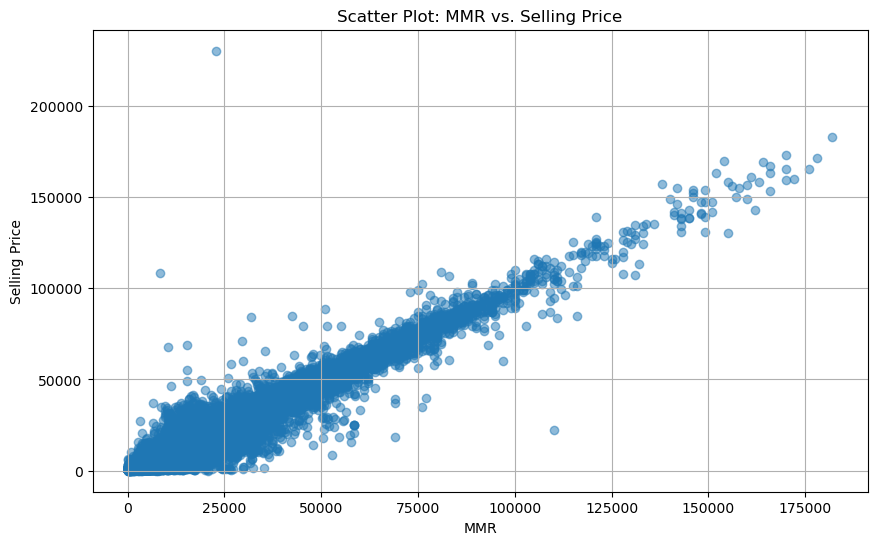

In [118]:
#4.3 Create a scatter plot with the relationship.

plt.figure(figsize=(10, 6))
plt.scatter(df['mmr'], df['sellingprice'], alpha=0.5)
plt.title('Scatter Plot: MMR vs. Selling Price')
plt.xlabel('MMR')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()

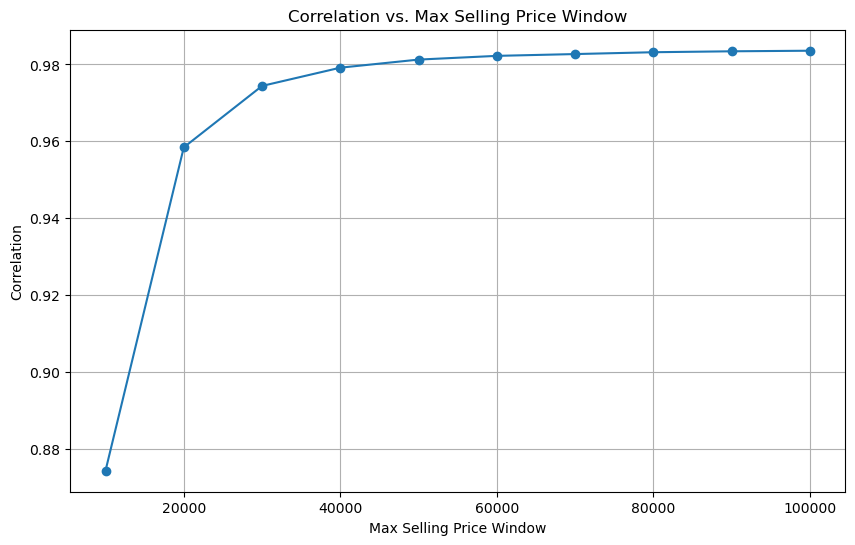

In [119]:
#4.4  Create a graph that shows how the correlation changes.

plt.figure(figsize=(10, 6))
plt.plot(selling_price_window, correlation_values, marker='o')
plt.title('Correlation vs. Max Selling Price Window')
plt.xlabel('Max Selling Price Window')
plt.ylabel('Correlation')
plt.grid(True)
plt.show()


## Question 5. How does the distribution of `salesprice` vary by make for cars made between 2010-2015?
- Use the 10 most common makes (your cleaned version of this column).  
- Create a graph that answers this question.

In [120]:
filter_data = df[(df['year'] >= 2010) & (df['year'] <= 2015)]
top_10_makes = filter_data['make'].value_counts().nlargest(10).index.tolist()

In [121]:
top_10_makes

['ford',
 'nissan',
 'chevrolet',
 'toyota',
 'dodge',
 'hyundai',
 'honda',
 'kia',
 'infiniti',
 'bmw']

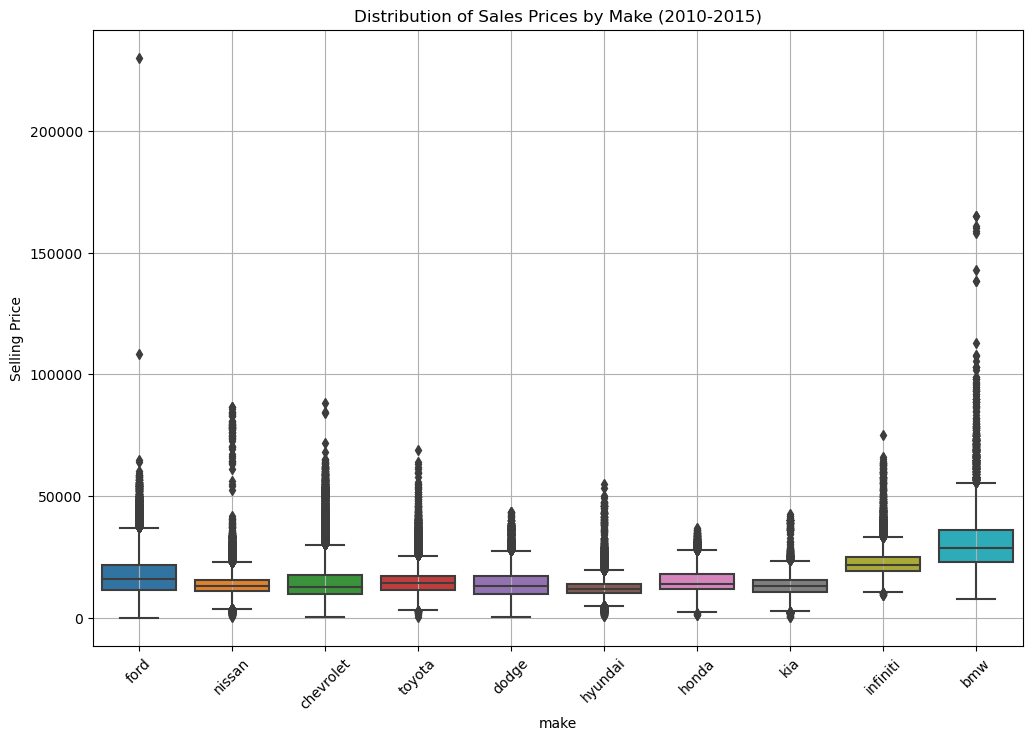

In [122]:
import seaborn as sns
filter_data = filter_data[filter_data['make'].isin(top_10_makes)]
plt.figure(figsize=(12, 8))
sns.boxplot(data=filter_data, x='make', y='sellingprice', order=top_10_makes)
plt.xticks(rotation=45)
plt.title('Distribution of Sales Prices by Make (2010-2015)')
plt.xlabel('make')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()